# Lab 4: Fuzzy Foundations & Visualisation

In [1]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Configuring matplotlib for a  better display
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1 Crisp Sets vs. Fuzzy Sets
### Exercise 1.1: Crisp vs. Fuzzy Tallness

- Short: Triangle(150, 150, 175)
- Average: Triangle(160, 175, 190)
- Tall: Triangle(180, 200, 210)

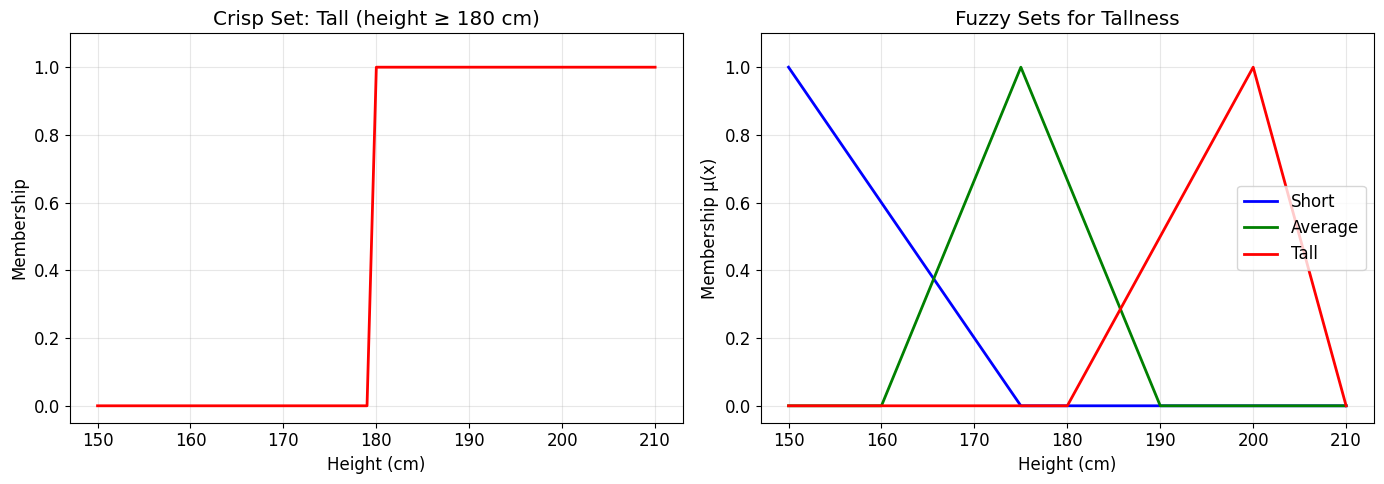

A person who is 184 cm tall:
 μ_average(184) = 0.40
 μ_tall(184) = 0.20
 → Partial membership in MULTIPLE sets simultaneously.


In [2]:
# Universe of discourse: height in cm
x_height = np.arange(150, 211, 1)

# --- Crisp set: tall if height >= 180 ---
crisp_tall = np.where(x_height >= 180, 1.0, 0.0)
# --- Fuzzy sets ---
short = fuzz.trimf(x_height, [150, 150, 175])
average = fuzz.trimf(x_height, [160, 175, 190])
tall = fuzz.trimf(x_height, [180, 200, 210])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Crisp
ax1.plot(x_height, crisp_tall, 'r-', linewidth=2)
ax1.set_title('Crisp Set: Tall (height ≥ 180 cm)')
ax1.set_xlabel('Height (cm)')
ax1.set_ylabel('Membership')
ax1.set_ylim(-0.05, 1.1)

# Fuzzy
ax2.plot(x_height, short, 'b-', linewidth=2, label='Short')
ax2.plot(x_height, average, 'g-', linewidth=2, label='Average')
ax2.plot(x_height, tall, 'r-', linewidth=2, label='Tall')
ax2.set_title('Fuzzy Sets for Tallness')
ax2.set_xlabel('Height (cm)')
ax2.set_ylabel('Membership μ(x)')
ax2.set_ylim(-0.05, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

# Demonstrate partial membership
height = 184
mu_avg = fuzz.interp_membership(x_height, average, height)
mu_tall = fuzz.interp_membership(x_height, tall, height)

print(f"A person who is {height} cm tall:")
print(f" μ_average({height}) = {mu_avg:.2f}")
print(f" μ_tall({height}) = {mu_tall:.2f}")
print(f" → Partial membership in MULTIPLE sets simultaneously.")

## 2. Common Membership Functions
### Exercise 2.1: Plot All Four Membership Function Types

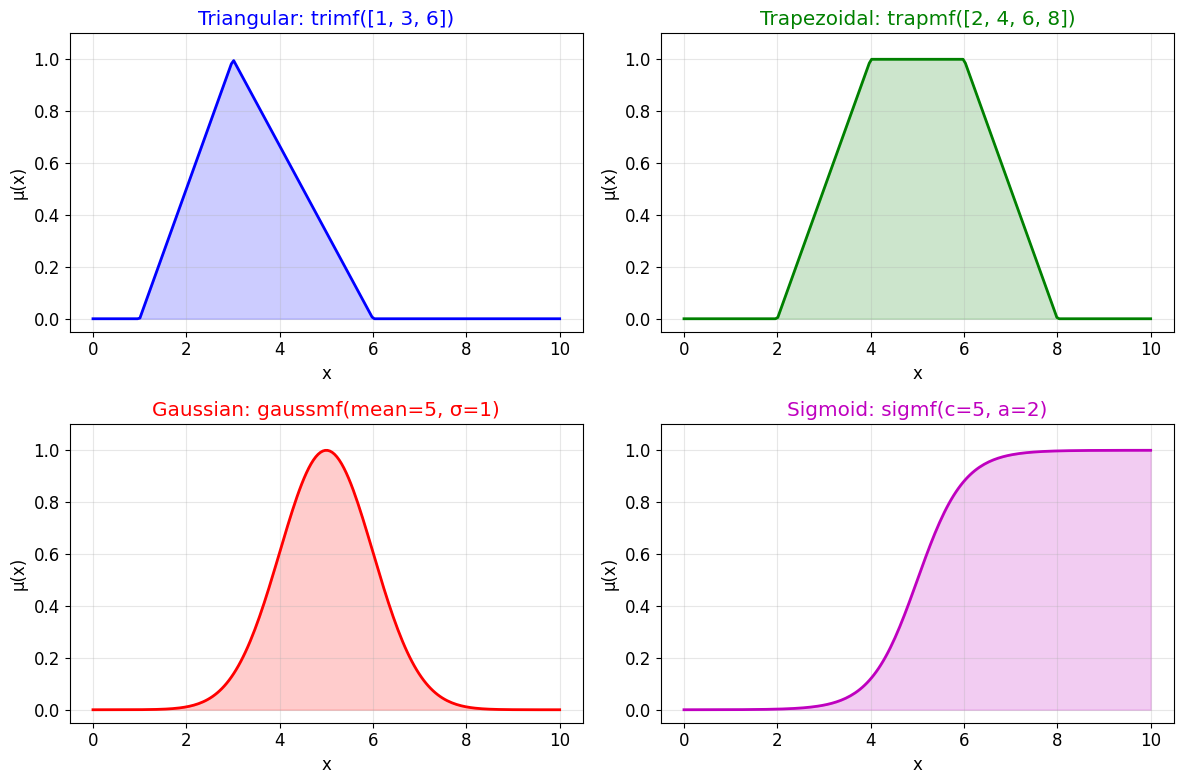

In [3]:
x = np.linspace(0, 10, 200)

# Triangular: peak at 3
triangular = fuzz.trimf(x, [1, 3, 6])

# Trapezoidal: plateau from 4 to 6
trapezoidal = fuzz.trapmf(x, [2, 4, 6, 8])

# Gaussian: centred at 5, sigma=1
gaussian = fuzz.gaussmf(x, 5, 1)

# Sigmoid: inflection at 5, slope=2 (positive = rising)
sigmoid = fuzz.sigmf(x, 5, 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(x, triangular, 'b-', linewidth=2)
axes[0, 0].set_title('Triangular: trimf([1, 3, 6])', color='b')
axes[0, 0].fill_between(x, triangular, alpha=0.2, color='b')

axes[0, 1].plot(x, trapezoidal, 'g-', linewidth=2)
axes[0, 1].set_title('Trapezoidal: trapmf([2, 4, 6, 8])', color='g')
axes[0, 1].fill_between(x, trapezoidal, alpha=0.2, color='g')

axes[1, 0].plot(x, gaussian, 'r-', linewidth=2)
axes[1, 0].set_title('Gaussian: gaussmf(mean=5, σ=1)', color='r')
axes[1, 0].fill_between(x, gaussian, alpha=0.2, color='r')

axes[1, 1].plot(x, sigmoid, 'm-', linewidth=2)
axes[1, 1].set_title('Sigmoid: sigmf(c=5, a=2)', color='m')
axes[1, 1].fill_between(x, sigmoid, alpha=0.2, color='m')

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Exercise 2.2: The Dapping Example — Defining Linguistic Variables

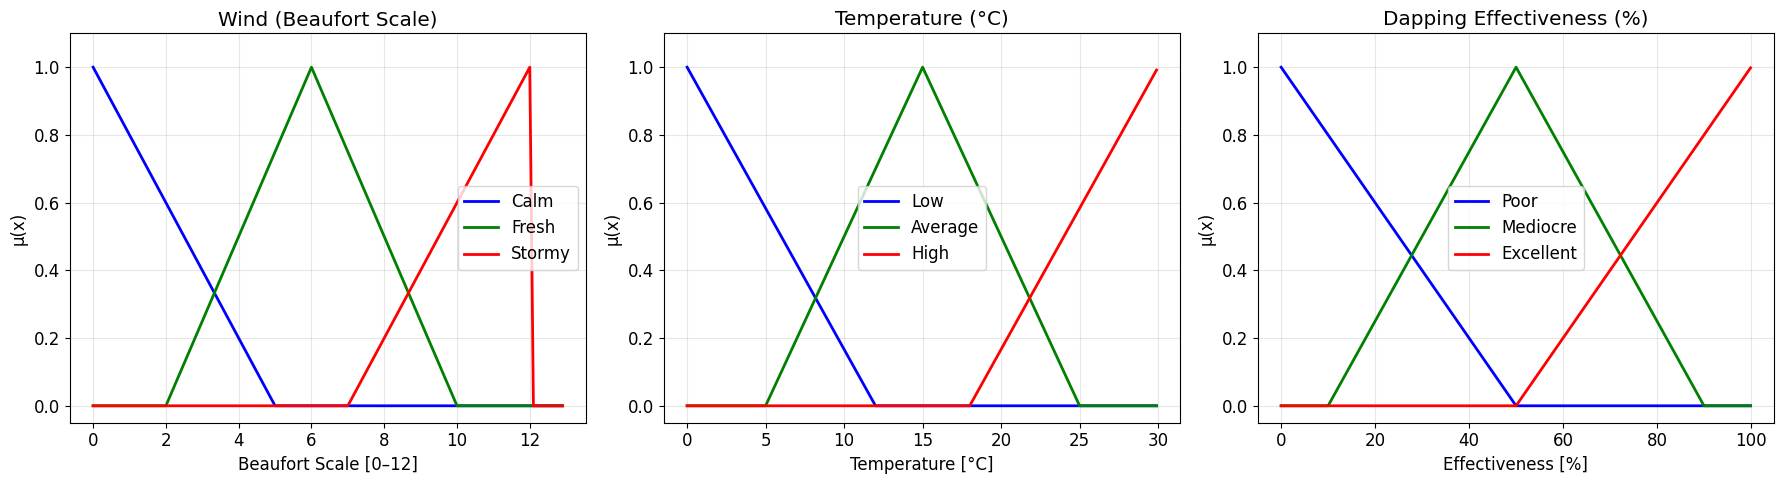

In [5]:
# --- Define universes of discourse ---
x_wind = np.arange(0, 13, 0.1) # Beaufort scale 0-12
x_temp = np.arange(0, 30, 0.1) # Temperature in Celsius
x_dap = np.arange(0, 100, 0.1) # Dapping effectiveness in percentage

# --- Wind membership functions ---
wind_calm = fuzz.trimf(x_wind, [0, 0, 5])
wind_fresh = fuzz.trimf(x_wind, [2, 6, 10])
wind_stormy = fuzz.trimf(x_wind, [7, 12, 12])

# --- Temperature membership functions ---
temp_low = fuzz.trimf(x_temp, [0, 0, 12])
temp_average = fuzz.trimf(x_temp, [5, 15, 25])
temp_high = fuzz.trimf(x_temp, [18, 30, 30])

# --- Dapping membership functions ---
dap_poor = fuzz.trimf(x_dap, [0, 0, 50])
dap_mediocre = fuzz.trimf(x_dap, [10, 50, 90])
dap_excellent = fuzz.trimf(x_dap, [50, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Wind
ax1.plot(x_wind, wind_calm, 'b-', linewidth=2, label='Calm')
ax1.plot(x_wind, wind_fresh, 'g-', linewidth=2, label='Fresh')
ax1.plot(x_wind, wind_stormy, 'r-', linewidth=2, label='Stormy')
ax1.set_title('Wind (Beaufort Scale)')
ax1.set_xlabel('Beaufort Scale [0–12]')
ax1.set_ylabel('μ(x)')
ax1.legend()

# Temperature
ax2.plot(x_temp, temp_low, 'b-', linewidth=2, label='Low')
ax2.plot(x_temp, temp_average, 'g-', linewidth=2, label='Average')
ax2.plot(x_temp, temp_high, 'r-', linewidth=2, label='High')
ax2.set_title('Temperature (°C)')
ax2.set_xlabel('Temperature [°C]')
ax2.set_ylabel('μ(x)')
ax2.legend()

# Dapping
ax3.plot(x_dap, dap_poor, 'b-', linewidth=2, label='Poor')
ax3.plot(x_dap, dap_mediocre, 'g-', linewidth=2, label='Mediocre')
ax3.plot(x_dap, dap_excellent, 'r-', linewidth=2, label='Excellent')
ax3.set_title('Dapping Effectiveness (%)')
ax3.set_xlabel('Effectiveness [%]')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Exercise 2.3: Computing Membership Degrees

For the inputs wind = 8 (Beaufort) and temperature = 10°C, compute the membership degree in every fuzzy set.

In [6]:
# Crisp inputs
wind_val = 8
temp_val = 10

# Fuzzify wind
mu_calm = fuzz.interp_membership(x_wind, wind_calm, wind_val)
mu_fresh = fuzz.interp_membership(x_wind, wind_fresh, wind_val)
mu_stormy = fuzz.interp_membership(x_wind, wind_stormy, wind_val)

# Fuzzify temperature
mu_low = fuzz.interp_membership(x_temp, temp_low, temp_val)
mu_average = fuzz.interp_membership(x_temp, temp_average, temp_val)
mu_high = fuzz.interp_membership(x_temp, temp_high, temp_val)

print(f"Fuzzification for wind = {wind_val}, temperature = {temp_val}")
print(f"{'─' * 45}")
print(f" μ_calm({wind_val}) = {mu_calm:.4f}")
print(f" μ_fresh({wind_val}) = {mu_fresh:.4f}")
print(f" μ_stormy({wind_val}) = {mu_stormy:.4f}")
print()
print(f" μ_low({temp_val}) = {mu_low:.4f}")
print(f" μ_average({temp_val}) = {mu_average:.4f}")
print(f" μ_high({temp_val}) = {mu_high:.4f}")

Fuzzification for wind = 8, temperature = 10
─────────────────────────────────────────────
 μ_calm(8) = 0.0000
 μ_fresh(8) = 0.5000
 μ_stormy(8) = 0.2000

 μ_low(10) = 0.1667
 μ_average(10) = 0.5000
 μ_high(10) = 0.0000
